
<a href="https://www.zero-grad.com/">
         <img alt="Zero Grad" src="https://i.postimg.cc/J4xdQKmg/dl-banner.png" >
      </a>

# Mnist data


In [ ]:
from keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()


c:\Users\ahmad\anaconda3\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
c:\Users\ahmad\anaconda3\lib\site-packages\numpy\.libs\libopenblas.EL2C6PLE4ZYW3ECEVIV3OXXGRN2NRFM2.gfortran-win_amd64.dll
c:\Users\ahmad\anaconda3\lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


In [ ]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape


((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [ ]:
X_train.min(), X_train.max(), X_test.min(), X_test.max()


(0, 255, 0, 255)

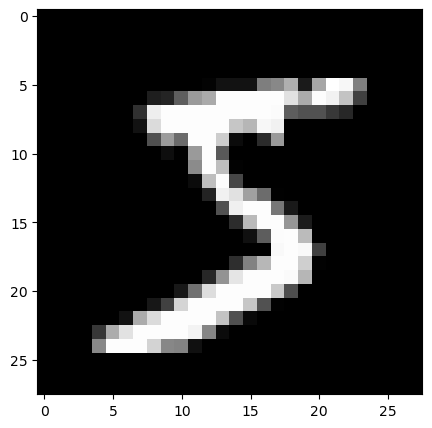

In [ ]:
# Visualize a sample image
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 5))
plt.imshow(X_train[0], cmap='gray')


In [ ]:
# Flatten and Normalize the images
X_train = X_train.reshape(-1, 784) / 255
X_test = X_test.reshape(-1, 784) / 255


In [ ]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape


((60000, 784), (60000,), (10000, 784), (10000,))

In [ ]:
X_train.min(), X_train.max(), X_test.min(), X_test.max()


(0.0, 1.0, 0.0, 1.0)

In [ ]:
X_train[0]


array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [ ]:
y_train[0]


5

# Keras Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical


In [ ]:
# Convert labels to categorical one-hot encoding
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)


In [ ]:
y_train.shape, y_test.shape


((60000, 10), (10000, 10))

In [ ]:
y_train[0]


array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.], dtype=float32)

In [ ]:
# Build the model.
model = Sequential([
    Dense(64, activation='relu', input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile the model.
model.compile(optimizer='Adam', loss='categorical_crossentropy',
              metrics=['accuracy'])

# Model summary.
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                50240     
                                                                 
 dense_1 (Dense)             (None, 64)                4160      
                                                                 
 dense_2 (Dense)             (None, 10)                650       
                                                                 
Total params: 55,050
Trainable params: 55,050
Non-trainable params: 0
_________________________________________________________________


## Model Summary

> First Hidden Layer
* No. of inputs:  784
* No. of neurons in hidden layer 1:  64
* Total No. of Parameters:  784*64 (Input-hidden1 weights) + 64 (hidden1 biases)= 50240

> Second Hidden Layer
* No. of inputs:  64
* No. of neurons in hidden layer 2:  64
* Total No. of Parameters:  64*64 (hidden1-hidden2 weights) + 64 (hidden2 biases)= 4160

> Output Layer
* No. of inputs:  64
* No. of neurons in output layer:  10
* Total No. of Parameters:  64*10 (hidden2-output weights) + 10 (output biases)= 650

> Total No. of Parameters:  50240+4160+650= 55050

## Alternative Model Building

1. Define then add layers with activation
```
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(784,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))
 ```


2. Define then add layers wthout activation
```
from tensorflow.keras.layers import Activation
model = Sequential()
model.add(Dense(64, input_dim=784))
model.add(Activation('relu'))
model.add(Dense(64))
model.add(Activation('relu'))
model.add(Dense(10))
model.add(Activation('softmax'))
```


3. Functional API syntax
```
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
inputs = Input(shape=(784,))
x = Dense(64, activation='relu')(inputs)
x = Dense(64, activation='relu')(x)
predictions = Dense(10, activation='softmax')(x)
model = Model(inputs=inputs, outputs=predictions)
```

In [ ]:
# Train the model.
model.fit(X_train, y_train, epochs=10, batch_size=32)
print("Training complete.\n")

# Evaluate the model.
print("Evaluating the model on test data...")
model.evaluate(X_test, y_test)


Epoch 1/10
1875/1875 [==============================] - 9s 4ms/step - loss: 0.2724 - accuracy: 0.9197
Epoch 2/10
1875/1875 [==============================] - 8s 5ms/step - loss: 0.1187 - accuracy: 0.9652
Epoch 3/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0848 - accuracy: 0.9737
Epoch 4/10
1875/1875 [==============================] - 5s 3ms/step - loss: 0.0675 - accuracy: 0.9798
Epoch 5/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0546 - accuracy: 0.9829
Epoch 6/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0459 - accuracy: 0.9852
Epoch 7/10
1875/1875 [==============================] - 5s 2ms/step - loss: 0.0393 - accuracy: 0.9873
Epoch 8/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0338 - accuracy: 0.9891
Epoch 9/10
1875/1875 [==============================] - 5s 2ms/step - loss: 0.0284 - accuracy: 0.9904
Epoch 10/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.026

[0.10081475973129272, 0.9753999710083008]

In [ ]:
# Batch vs Epoch
batch_size = 32
training_samples = 60000
iterations_per_epoch = training_samples/batch_size
iterations_per_epoch


1875.0

# Some Keras Options

In [ ]:
# Activation functions
from tensorflow.keras.activations import relu, sigmoid, linear, softmax, tanh

# Optimizer
from tensorflow.keras.optimizers import SGD, RMSprop, Adam

# loss function
from tensorflow.keras.losses import mean_squared_error, mean_absolute_error, \
    binary_crossentropy, categorical_crossentropy, sparse_categorical_crossentropy


In [ ]:
def build_model(hidden_activation='relu', output_activation='softmax', optimizer='adam', loss='categorical_crossentropy'):
    model = Sequential()
    model.add(Dense(64, input_shape=(784,), activation=hidden_activation))
    model.add(Dense(64, activation=hidden_activation))
    model.add(Dense(10, activation=output_activation))
    model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])
    return model


In [ ]:
my_model = build_model()
my_model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 64)                50240     
                                                                 
 dense_4 (Dense)             (None, 64)                4160      
                                                                 
 dense_5 (Dense)             (None, 10)                650       
                                                                 
Total params: 55,050
Trainable params: 55,050
Non-trainable params: 0
_________________________________________________________________


In [ ]:
my_model.fit(X_train, y_train, epochs=10, batch_size=32)


Epoch 1/10
1875/1875 [==============================] - 9s 4ms/step - loss: 0.2824 - accuracy: 0.9183
Epoch 2/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.1264 - accuracy: 0.9613
Epoch 3/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0923 - accuracy: 0.9710
Epoch 4/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0735 - accuracy: 0.9769
Epoch 5/10
1875/1875 [==============================] - 5s 3ms/step - loss: 0.0600 - accuracy: 0.9813
Epoch 6/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0498 - accuracy: 0.9843
Epoch 7/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0422 - accuracy: 0.9865
Epoch 8/10
1875/1875 [==============================] - 8s 4ms/step - loss: 0.0350 - accuracy: 0.9889
Epoch 9/10
1875/1875 [==============================] - 5s 3ms/step - loss: 0.0324 - accuracy: 0.9893
Epoch 10/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.027

# History object

In [ ]:
history = model.fit(X_train, y_train, validation_split=0.2,
                    epochs=10, batch_size=32)


Epoch 1/10
1500/1500 [==============================] - 5s 3ms/step - loss: 0.0212 - accuracy: 0.9927 - val_loss: 0.0238 - val_accuracy: 0.9929
Epoch 2/10
1500/1500 [==============================] - 4s 3ms/step - loss: 0.0194 - accuracy: 0.9931 - val_loss: 0.0410 - val_accuracy: 0.9869
Epoch 3/10
1500/1500 [==============================] - 4s 3ms/step - loss: 0.0177 - accuracy: 0.9937 - val_loss: 0.0339 - val_accuracy: 0.9893
Epoch 4/10
1500/1500 [==============================] - 7s 5ms/step - loss: 0.0147 - accuracy: 0.9951 - val_loss: 0.0555 - val_accuracy: 0.9844
Epoch 5/10
1500/1500 [==============================] - 7s 5ms/step - loss: 0.0152 - accuracy: 0.9948 - val_loss: 0.0393 - val_accuracy: 0.9873
Epoch 6/10
1500/1500 [==============================] - 5s 3ms/step - loss: 0.0139 - accuracy: 0.9954 - val_loss: 0.0433 - val_accuracy: 0.9868
Epoch 7/10
1500/1500 [==============================] - 4s 3ms/step - loss: 0.0127 - accuracy: 0.9957 - val_loss: 0.0574 - val_accuracy:

In [ ]:
batch_size = 32
training_samples = 0.8 * 60000
iterations_per_epoch = training_samples/batch_size
iterations_per_epoch


1500.0

In [ ]:
print(history.params)


{'verbose': 1, 'epochs': 10, 'steps': 1500}


In [ ]:
print(history.history.keys())


dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


In [ ]:
import pandas as pd
history_df = pd.DataFrame(history.history)
history_df.head()


,loss,accuracy,val_loss,val_accuracy
0,0.021234,0.992750,0.023839,0.992917
1,0.019443,0.993104,0.041039,0.986917
2,0.017706,0.993750,0.033882,0.989250
3,0.014695,0.995146,0.055478,0.984417
4,0.015151,0.994812,0.039332,0.987333


<Axes: >

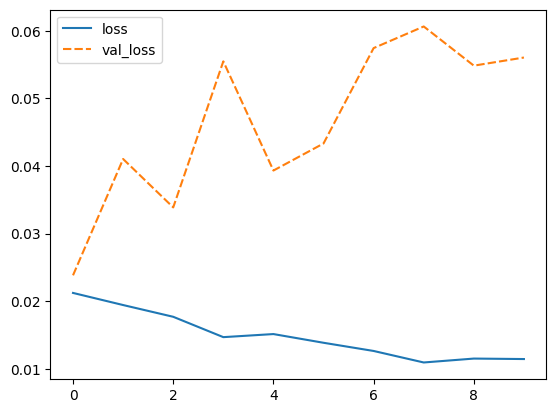

In [ ]:
# Plot the loss
import seaborn as sns
sns.set_style()
sns.lineplot(data=history_df[['loss', 'val_loss']])


<Axes: >

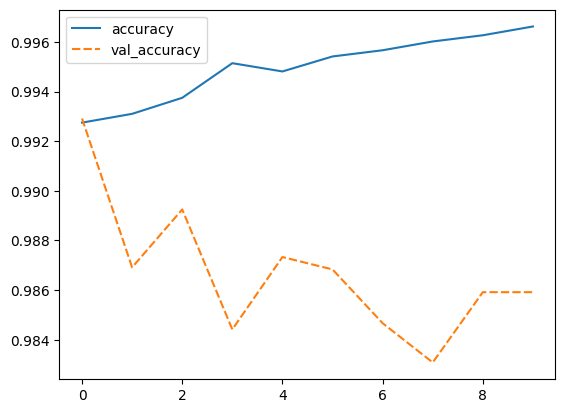

In [ ]:
# Plot the accuracy
sns.lineplot(data=history_df[['accuracy', 'val_accuracy']])
